# Fitting 1D dataset

In this example, we find the least square solution of a simple linear
equation.


In [1]:
import os

import spectrochempy as scp

"<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAABgAAAAYCAYAAADgdz34AAAAAXNSR0IArs4c6QAAAAlw SFlzAAAJOgAACToB8GSSSgAAAetpVFh0WE1MOmNvbS5hZG9iZS54bXAAAAAAADx4OnhtcG1ldGEgeG1sbnM6eD0iYWRvYmU6bnM6 bWV0YS8iIHg6eG1wdGs9IlhNUCBDb3JlIDUuNC4wIj4KICAgPHJkZjpSREYgeG1sbnM6cmRmPSJodHRwOi8vd3d3LnczLm9yZy8x OTk5LzAyLzIyLXJkZi1zeW50YXgtbnMjIj4KICAgICAgPHJkZjpEZXNjcmlwdGlvbiByZGY6YWJvdXQ9IiIKICAgICAgICAgICAg eG1sbnM6eG1wPSJodHRwOi8vbnMuYWRvYmUuY29tL3hhcC8xLjAvIgogICAgICAgICAgICB4bWxuczp0aWZmPSJodHRwOi8vbnMu YWRvYmUuY29tL3RpZmYvMS4wLyI+CiAgICAgICAgIDx4bXA6Q3JlYXRvclRvb2w+bWF0cGxvdGxpYiB2ZXJzaW9uIDIuMS4wLCBo dHRwOi8vbWF0cGxvdGxpYi5vcmcvPC94bXA6Q3JlYXRvclRvb2w+CiAgICAgICAgIDx0aWZmOk9yaWVudGF0aW9uPjE8L3RpZmY6 T3JpZW50YXRpb24+CiAgICAgIDwvcmRmOkRlc2NyaXB0aW9uPgogICA8L3JkZjpSREY+CjwveDp4bXBtZXRhPgqNQaNYAAAGiUlE QVRIDY1We4xU1Rn/3XPuYx47u8w+hnU38hTcuoUEt/6D2y4RB0ME1BoEd9taJaKh9CFiN7YGp7appUAMNmktMZFoJTYVLVQ0smsy 26CN0SU1QgsuFAaW3WVmx33N677O6XfuyoIxTXqSO/fec+75fd93vt/3/UbDV0aKSZmCpkFMLz3T9utuu2N+o98aDSMBKVAo89z5 y+zEz3ZafcCOfvWdlGCalqKn1Bf71CygTd+mf1esSOnpdMpTb+vWpTZuWVfe3jLPa5tzHYNm0T5N0gpdkkHaDBeGBU6d1/t/fyS8 +/CbqdfUvmsx1PuMgc2bNxv79u1zgd31r+7JH1jbIZKxWRXAcYUQ8IWvBfBXNjEuJWPgMA02NR7C3/pYT9fjdZ3A9tGrWF8YSJHn qcDz3y7q2T967PZv+gnYJdd1mEZ+62zGDQV/dQgKhmLzDNOXCEWM3j6eTT5Y3w78dOBKJLR1PQf+4ivPj76UPZnssBN+wbM9Aet/ AV81Mf1EEULXYfOobvX2WWQk0aoioXwwSmirOlioY0mu8BIouzYl7P8GV3vpqCCEZvlFz769w08oLDWvyKIyL1asSm28d6WfzA97 ztvvV1kexUMsmhlkULEkuGYmFYC6AvfUrITnwUKl5K79lkjeSSRRTCTbQPd95e1WzMbZSya74XoXAxctCllCnbECMOjZNGRwvzIX nD85wbkMmKK+U045Dtdi8Qp+SAxU2GTg2bYlC9224pgvmSb54vkVTBQYyhUt2KjAMyMmPjwRQW5Mh2WKwJhlBh6jVGagFM84wZnQ 4bpC0Rt4pk1PbSt0NDcxDA5xryosDHWgtbM0DGZDWLSoiDMDYeQnGVrmOThxLozB0RAaahzkJzjKNqcIQBymJFMkOlN8Dqjpg0XY Tx5xO/QbmmUrqIjGJznq47TqTaClKYfjp+PInLMwnOdYvtQBZ2XcunQY+VwIo4U4muoFEjVEFE6lQyEUKzHYfgQG9ylCyngU+Cxj tOqxCDGHcCsOMCs6iQul5ZiStdATYxjMZXDLTUVwLY8Jey4uOh2IxjwsrP8UXJYxUrkZrghBahzV5iXU6gNkq0Z1EzIsUBUSCV2n EOHo0LVxHCpuxabJJdhi5PFnvw5vLXwXIfNZvD/+JNo/X40NegE54sUaazl+UL8XD1x+FB9Ijjt4EQfdGN6J/x131LwIV9ap/AYs 0x1fz1ZKFbh6A7qKy/By9Dg6G36Ep91vUJJ15Cqr0Z67E8/HzmBrw1OwxWyM+3Mo6BAuSB17oyfx0Oyl2DN0Hqs/70Cx6hBCvESF UY1ShWXZZEE7OTAYxZzaPH4TuoiusZvRnunFy2NbiHYuBp2vB66srX4vMEjpRKPxKXmnoQ4+Mn4DPiv8CYcrs3GfNUXJLtM+alSO hrMj/KT+wBNW3+E/2liywNO3iSflbaFva/+stGDTxE0E9Sjaox8HBhxpEamzMGSEaFKg+mjEddzDh1MxTDq3YV1kGBsjfwW3S9Cq anjmko+ndlb1UR3s6K8JlfphNWq9Ew/7c61T2BB/EbcaNkb8GBaE0tANH7/M34PLdhJDzjIcL9xPbdTG6zyM72Y+wXPHmvB489No fm0b5HnbQ9Rgp/7DSSd29AeVvPeNyK6JcYl/yQVi5dBjuGvoV/gaJe47s45QUxrDmcYX0MBsdF7egvXZ7+O0vZA4X8QmOQWjlSK7 RDz5wIM30gp9UbWcGjXxhzdDu1SiNSpx6kcQB57rPnr/3dlkZarWLnlRq5oPET1dOCIOk4wALib9eeS5iygfhkd09H0DWphB/+gs +PcOAS+ssrFmmXXgVfR0de9cpbAJfH3Q1jofW9DZk56dDcVsq9YcsoUMEd1qyLoT3BX1YiyHMJuk97hyjqIoE91t+NcTLeN0ZrfM oXatZbu6G0h4VG+ibqq0IJVK6cAjo6serG3vSUezCMct0yQeSOFJSUImqb2qbknUpDqlZxE0QZ+ZUpSlZx79h4Nda6zef9dlk121 JDjbR5XggPRZlRnS6bRQRtLpn4++cuie/Yvn2svmNxuLw9WCcYIl4fEoTEGiSTUqJdfgU+8ROqf1iMkLzS389YtNPXc/PH8l8ONB JZkHD+4JtD04HmVEDWWErmBhzV2/2LB1bemJG6krzv2S6NOHUgtEP0Oif5pE/3fHoruP7N8RiP61GArzSwbUhJJQpXJKiKbfr/3b IhKq76sKPUdF9NW/LSqfSn6vjv8C45H/6FSgvZQAAAAASUVORK5CYII=' style='height:25px; border-radius:12px; display:inline-block; float:left; vertical-align:middle'>",SpectroChemPy's API - v.0.6.11.dev5© Copyright 2014-2025 - A.Travert & C.Fernandez @ LCS


Let\'s take an IR spectrum


In [2]:
nd = scp.NDDataset.read_omnic(os.path.join("irdata", "nh4y-activation.spg"))

and select only the OH region:


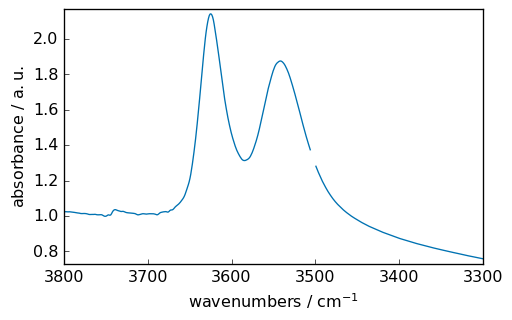

In [3]:
ndOH = nd[54, 3800.0:3300.0]
# masking
ndOH[:, 3505.0:3500.0] = scp.MASKED
_ = ndOH.plot()

Perform a Fit Fit parameters are defined in a script (a single text as
below)


In [4]:
script = """
#-----------------------------------------------------------
# syntax for parameters definition:
# name: value, low_bound,  high_bound
# available prefix:
#  # for comments
#  * for fixed parameters
#  $ for variable parameters
#  > for reference to a parameter in the COMMON block
#    (> is forbidden in the COMMON block)
# common block parameters should not have a _ in their names
#-----------------------------------------------------------
#

COMMON:
# common parameters ex.
# $ gwidth: 1.0, 0.0, none
$ gratio: 0.1, 0.0, 1.0

MODEL: LINE_1
shape: asymmetricvoigtmodel
    * ampl:  1.1, 0.0, none
    $ pos:   3620, 3400.0, 3700.0
    $ ratio: 0.0147, 0.0, 1.0
    $ asym: 0.1, 0, 1
    $ width: 50, 0, 1000

MODEL: LINE_2
shape: asymmetricvoigtmodel
    $ ampl:  0.8, 0.0, none
    $ pos:   3540, 3400.0, 3700.0
    > ratio: gratio
    $ asym: 0.1, 0, 1
    $ width: 50, 0, 1000

"""

create an Optimize object


In [5]:
f1 = scp.Optimize(log_level="INFO")

Show plot and the starting model using the dry parameters (of course it
is advisable to be as close as possible of a good expectation


 **************************************************


 Starting parameters:


 **************************************************



 COMMON:
	$ gratio:     0.1000, 0.0, 1.0

 MODEL: line_1
 shape: asymmetricvoigtmodel
	* ampl:     1.1000, 0.0, none
	$ asym:     0.1000, 0, 1
	$ pos:  3620.0000, 3400.0, 3700.0
	$ ratio:     0.0147, 0.0, 1.0
	$ width:    50.0000, 0, 1000

 MODEL: line_2
 shape: asymmetricvoigtmodel
	$ ampl:     0.8000, 0.0, none
	$ asym:     0.1000, 0, 1
	$ pos:  3540.0000, 3400.0, 3700.0
	> ratio:gratio
	$ width:    50.0000, 0, 1000



 numbers of components: 2


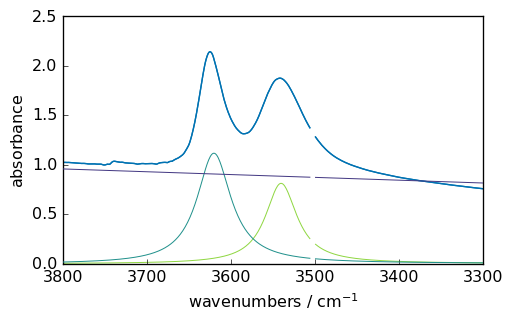

In [6]:
f1.script = script

# set dry and continue to show starting model
# reset dry and continue to show starting model
f1.dry = True
f1.autobase = True
f1.fit(ndOH)

# get some information
scp.info_(f"numbers of components: {f1.n_components}")
ndOH.plot()
ax = (f1.components[:]).plot(clear=False)
ax.autoscale(enable=True, axis="y")

Now perform a fit with maximum 1000 iterations


In [7]:
f1.max_iter = 1000
_ = f1.fit(ndOH)

 **************************************************


 Result:


 **************************************************



 COMMON:
	$ gratio:     0.3458, 0.0, 1.0

 MODEL: line_1
 shape: asymmetricvoigtmodel
	* ampl:     1.1000, 0.0, none
	$ asym:     0.7716, 0, 1
	$ pos:  3623.4044, 3400.0, 3700.0
	$ ratio:     0.4394, 0.0, 1.0
	$ width:    43.5995, 0, 1000

 MODEL: line_2
 shape: asymmetricvoigtmodel
	$ ampl:     0.9001, 0.0, none
	$ asym:     1.0000, 0, 1
	$ pos:  3536.9977, 3400.0, 3700.0
	> ratio:gratio
	$ width:    79.4888, 0, 1000



Show the result


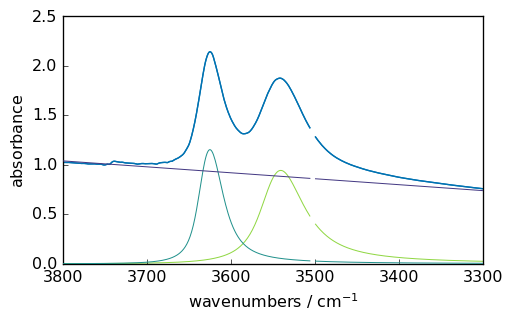

In [8]:
ndOH.plot()
ax = (f1.components[:]).plot(clear=False)
ax.autoscale(enable=True, axis="y")

plotmerit


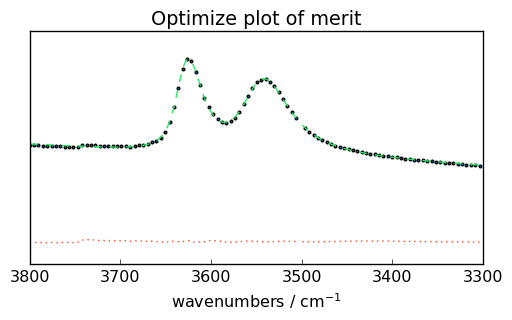

In [9]:
som = f1.inverse_transform()
_ = f1.plotmerit(ndOH, som, method="scatter", markevery=5, markersize=2, lw=2)

This ends the example ! The following line can be uncommented if no plot
shows when running the .py script with python


In [10]:
# scp.show()